In [14]:
#Importing Libraries
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

dataset_path=r"D:\Gender & Age Detection\UTKFace"

In [2]:
print(len(os.listdir(dataset_path)))

23708


In [3]:
#Organizing data into lists
genders,ages,images=[],[],[]
for filename in os.listdir(dataset_path)[:5000]:
    parts = filename.split("_")
    age=int(parts[0])
    gender=int(parts[1])
    img = cv2.imread(os.path.join(dataset_path, filename))
    if img is not None:
        img = cv2.resize(img, (64, 64))
        images.append(img)
        ages.append(age)
        genders.append(gender)

In [4]:
print(len(genders),len(ages),len(images))

5000 5000 5000


In [5]:
#Always better to do numerical computations in ML
images = np.array(images)
ages = np.array(ages)
genders = np.array(genders)

In [6]:
print(images.shape)
print(ages.shape)
print(genders.shape)

(5000, 64, 64, 3)
(5000,)
(5000,)


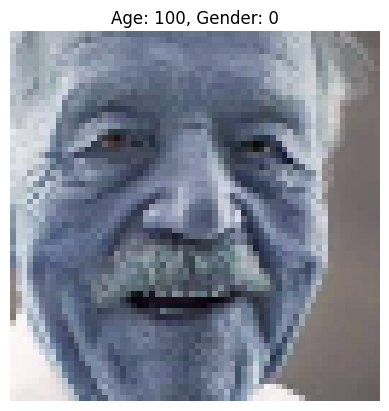

In [7]:
plt.imshow(images[0])
plt.title(f"Age: {ages[0]}, Gender: {genders[0]}")
plt.axis("off")
plt.show()

In [8]:
#Converting pixel values from 0 to 255 -> 0 or 1
images = images / 255.0

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_gender_train, y_gender_test = train_test_split(
    images, genders, test_size=0.2, random_state=42
)

In [10]:
print(X_train.shape)
print(X_test.shape)

(4000, 64, 64, 3)
(1000, 64, 64, 3)


In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    MaxPooling2D(2,2),
    
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')   # binary classification
])

C:\Users\Ved\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.30.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\Ved\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.30.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\Ved\AppData\Roaming\Python\Python313\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.30.1 at tensorflow/core/framework/resource_handle.proto. Please update

In [12]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [13]:
model.fit(X_train, y_gender_train, epochs=5, validation_data=(X_test, y_gender_test))

Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 79ms/step - accuracy: 0.6607 - loss: 0.5925 - val_accuracy: 0.6490 - val_loss: 0.6318
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 90ms/step - accuracy: 0.7747 - loss: 0.4719 - val_accuracy: 0.7890 - val_loss: 0.4514
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 86ms/step - accuracy: 0.8027 - loss: 0.4213 - val_accuracy: 0.7900 - val_loss: 0.4484
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 92ms/step - accuracy: 0.8185 - loss: 0.3864 - val_accuracy: 0.7970 - val_loss: 0.4490
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 91ms/step - accuracy: 0.8338 - loss: 0.3588 - val_accuracy: 0.7770 - val_loss: 0.4871


In [36]:
test_img = X_test[0]

In [37]:
pred = model.predict(test_img.reshape(1, 64, 64, 3))
print(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
[[0.00102167]]


In [38]:
#Binary classifiction, porbability towards 1 more tends to female
if pred[0][0] > 0.5:
    print("Female")
else:
    print("Male")

Male


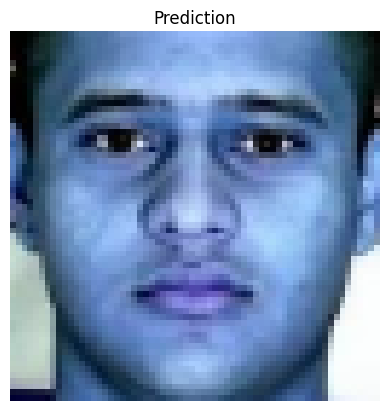

In [39]:
plt.imshow(test_img)
plt.title("Prediction")
plt.axis("off")
plt.show()